<a href="https://colab.research.google.com/github/Arma3071/Flyrank-AI-notebooks/blob/main/capstone_ctr_opportunity_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — CTR / Engagement Opportunity Scoring (Model vs. Baseline)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Arma3071/Flyrank-AI-notebooks/blob/main/capstone_ctr_opportunity_model.ipynb)

This continues the CTR/Engagement Opportunity Scoring lane from `w04_baseline_score.ipynb`, where the
baseline was a **hand-written rule**: score = (expected CTR for position − actual CTR) × impressions.

Here we turn that into a **learned model**, validate it honestly against the same rule on the same
held-out split, and produce a ranked action queue with reason codes.



## 0. Setup

In [1]:
!pip -q install duckdb pandas scikit-learn pyarrow matplotlib

import duckdb
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)


## 1. Connect to the warehouse

In [2]:
HF_TOKEN = ""  # <--Hugging Face read token here

con = duckdb.connect()
con.execute(f"""
CREATE SECRET (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

BASE = "hf://datasets/FlyRank/internship-warehouse"

# sanity check: list what's actually in the warehouse
con.sql(f"SELECT * FROM glob('{BASE}/**')").df().head(20)


,file
0,hf://datasets/FlyRank/internship-warehouse/.gi...
1,hf://datasets/FlyRank/internship-warehouse/REA...
2,hf://datasets/FlyRank/internship-warehouse/dim...
3,hf://datasets/FlyRank/internship-warehouse/dim...
4,hf://datasets/FlyRank/internship-warehouse/fac...
5,hf://datasets/FlyRank/internship-warehouse/fac...
6,hf://datasets/FlyRank/internship-warehouse/fac...
7,hf://datasets/FlyRank/internship-warehouse/fac...
8,hf://datasets/FlyRank/internship-warehouse/fac...
9,hf://datasets/FlyRank/internship-warehouse/fac...


In [3]:
for t in ["dim_clients", "dim_content", "fact_content_query_90d"]:
    print(f"--- {t} ---")
    con.sql(f"DESCRIBE SELECT * FROM read_parquet('{BASE}/{t}.parquet')").show()


--- dim_clients ---
┌─────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name     │ column_type │  null   │   key   │ default │  extra  │
│       varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ client_hash_id      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ is_active           │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ has_gsc_access      │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ has_ga4_access      │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ access_profile      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_created_date │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ client_updated_date │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_data_start      │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ ga4_data_start      │ DATE        │ YES   

## 2. Data contract

**Unit of analysis:** one row = one piece of content (`content_hash_id`) for one client, aggregated over
the trailing-90-day window shipped in `fact_content_query_90d`.

**Tables used:** `dim_content`, `dim_clients`, `fact_content_query_90d`.

**Label:** `underperforms_ctr` = 1 if a page's actual 90-day CTR sits below the CTR *expected for its
position bucket* — where "expected" is computed **from the training split only**, so the test split never
leaks into its own benchmark.

**Excluded (public-safe / leakage-safe):**
- unpublished or deleted content (`is_published = FALSE` or `is_deleted = TRUE`)
- any client name, domain, URL, or raw query text (we only ever touch hashed ids)
- the position-bucket CTR benchmark is fit on train rows only, then applied to test rows — the model
  never sees test-set outcomes before being scored on them
- no row from any one `client_hash_id` appears in both train and test (grouped split)

**Baseline to beat:** the Week-4 rule — `score = max(0, expected_ctr − actual_ctr) × impressions_90d`,
ranked and evaluated with **Precision@50** on the held-out split.

## 3. Build the content-level feature table

In [4]:
content_attrs = con.sql(f"""
SELECT
    content_hash_id,
    ANY_VALUE(client_hash_id)   AS client_hash_id,
    MAX(content_updated_date)   AS content_updated_date,
    MAX(last_optimized_date)    AS last_optimized_date,
    ANY_VALUE(content_type)     AS content_type,
    ANY_VALUE(word_count)       AS word_count,
    BOOL_OR(is_published)       AS is_published,
    BOOL_OR(is_deleted)         AS is_deleted
FROM read_parquet('{BASE}/dim_content.parquet')
GROUP BY content_hash_id
""").df()

content_perf = con.sql(f"""
SELECT
    content_hash_id,
    ANY_VALUE(client_hash_id) AS client_hash_id,
    MAX(window_end)           AS window_end,
    SUM(impressions_90d)      AS impressions_90d,
    SUM(clicks_90d)           AS clicks_90d,
    SUM(impressions_last30)   AS impressions_last30,
    SUM(clicks_last30)        AS clicks_last30,
    SUM(avg_position_90d * impressions_90d) / NULLIF(SUM(impressions_90d), 0) AS avg_position_90d,
    SUM(rare_query_count)                                                    AS rare_query_count,
    SUM(rare_impressions_share * impressions_90d) / NULLIF(SUM(impressions_90d), 0)       AS rare_impressions_share,
    SUM(anonymized_impressions_share * impressions_90d) / NULLIF(SUM(impressions_90d), 0) AS anonymized_impressions_share
FROM read_parquet('{BASE}/fact_content_query_90d.parquet')
GROUP BY content_hash_id
""").df()

df = (
    content_perf
    .merge(content_attrs.drop(columns=["client_hash_id"]), on="content_hash_id", how="inner")
)

df = df[(df["is_published"] == True) & (df["is_deleted"] == False)].copy()
df = df[df["impressions_90d"] > 0].copy()

df["ctr_90d"] = df["clicks_90d"] / df["impressions_90d"]
df["window_end"] = pd.to_datetime(df["window_end"])
df["content_updated_date"] = pd.to_datetime(df["content_updated_date"])
df["days_since_update"] = (df["window_end"] - df["content_updated_date"]).dt.days.clip(lower=0)

print(df.shape)
df.head(3)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(133801, 19)


,content_hash_id,client_hash_id,window_end,impressions_90d,clicks_90d,impressions_last30,clicks_last30,avg_position_90d,rare_query_count,rare_impressions_share,anonymized_impressions_share,content_updated_date,last_optimized_date,content_type,word_count,is_published,is_deleted,ctr_90d,days_since_update
0,content_5f6c0644690c7bda,client_08a6a72ff48e62c0,2026-06-30,49.0,0.0,19.0,0.0,35.040816,128.0,0.231834,0.598616,2026-02-25,NaT,keyword article,<NA>,True,False,0.0,125
1,content_5f6f16f9f290ff0b,client_08a6a72ff48e62c0,2026-06-30,70.0,0.0,4.0,0.0,13.385714,108.0,0.196429,0.553571,2026-04-19,NaT,keyword article,<NA>,True,False,0.0,72
2,content_5f7bba49f47a5348,client_08a6a72ff48e62c0,2026-06-30,238.0,0.0,0.0,0.0,5.407563,354.0,0.144472,0.556533,2026-04-19,NaT,keyword article,<NA>,True,False,0.0,72


In [5]:
bins = [0, 3, 10, 20, 50, 100000]
labels = ["1-3", "4-10", "11-20", "21-50", "51+"]
df["position_bucket"] = pd.cut(df["avg_position_90d"], bins=bins, labels=labels)

bins2 = [-1, 30, 90, 180, 365, 100000]
labels2 = ["<30d", "30-90d", "90-180d", "180-365d", "365d+"]
df["staleness_bucket"] = pd.cut(df["days_since_update"], bins=bins2, labels=labels2)

df = df.dropna(subset=["position_bucket"]).copy()
print(df.shape)


(132128, 21)


## 4. Grouped, leakage-safe split

Split by `client_hash_id` (not by row) so the same client never shows up in both train and test —
otherwise the model could "learn a client" instead of learning the underlying pattern.

In [6]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["client_hash_id"]))

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()

overlap = set(train_df["client_hash_id"]) & set(test_df["client_hash_id"])
assert len(overlap) == 0, "Client leakage across the split!"
print(f"train rows: {len(train_df):,}  |  test rows: {len(test_df):,}  |  client overlap: {len(overlap)}")


train rows: 115,726  |  test rows: 16,402  |  client overlap: 0


## 5. Baseline rule — fit the CTR benchmark on TRAIN only, score on TEST

This is exactly the Week-4 rule, but now the "expected CTR for this position" benchmark is computed
strictly from the training split, then applied to test rows it has never seen.

In [7]:
expected_ctr_by_bucket = (
    train_df.groupby("position_bucket", observed=True)["ctr_90d"].mean()
)
print(expected_ctr_by_bucket.round(4))

for split_df in (train_df, test_df):
    split_df["expected_ctr"] = split_df["position_bucket"].map(expected_ctr_by_bucket).astype(float)
    split_df["ctr_gap"] = split_df["expected_ctr"] - split_df["ctr_90d"]
    split_df["baseline_score"] = (split_df["ctr_gap"].clip(lower=0) * split_df["impressions_90d"]).round(2)
    split_df["underperforms_ctr"] = (split_df["ctr_90d"] < split_df["expected_ctr"]).astype(int)

print("\nTest-set label balance:")
print(test_df["underperforms_ctr"].value_counts(normalize=True).round(3))


position_bucket
1-3      0.0025
4-10     0.0030
11-20    0.0019
21-50    0.0009
51+      0.0002
Name: ctr_90d, dtype: float64

Test-set label balance:
underperforms_ctr
1    0.829
0    0.171
Name: proportion, dtype: float64


In [8]:
def precision_at_k(df_scored, score_col, label_col, k=50):
    top_k = df_scored.sort_values(score_col, ascending=False).head(k)
    return top_k[label_col].mean()

baseline_p50 = precision_at_k(test_df, "baseline_score", "underperforms_ctr", k=50)
print(f"Baseline rule  Precision@50 on test: {baseline_p50:.3f}  (~{round(baseline_p50*50)} of top 50 truly underperform)")


Baseline rule  Precision@50 on test: 1.000  (~50 of top 50 truly underperform)


## 6. Learned model

Same label (`underperforms_ctr`), same split — but the model gets to combine several signals instead of
a single position-bucket rule.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

feature_cols = [
    "avg_position_90d", "impressions_90d", "word_count", "days_since_update",
    "rare_query_count", "rare_impressions_share", "anonymized_impressions_share",
]
cat_cols = ["content_type"]

def make_X(split_df):
    num = split_df[feature_cols].fillna(0)
    cat = pd.get_dummies(split_df[cat_cols].astype(str), drop_first=True)
    return pd.concat([num, cat], axis=1)

X_train_raw = make_X(train_df)
X_test_raw  = make_X(test_df)
X_test_raw  = X_test_raw.reindex(columns=X_train_raw.columns, fill_value=0)  # align dummy cols

y_train = train_df["underperforms_ctr"]
y_test  = test_df["underperforms_ctr"]

model = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1)
model.fit(X_train_raw, y_train)

test_df["model_proba"] = model.predict_proba(X_test_raw)[:, 1]
test_df["model_pred"]  = (test_df["model_proba"] >= 0.5).astype(int)

model_p50 = precision_at_k(test_df, "model_proba", "underperforms_ctr", k=50)

print(f"Baseline rule  Precision@50: {baseline_p50:.3f}")
print(f"Random forest  Precision@50: {model_p50:.3f}")
print(f"\nModel F1:        {f1_score(y_test, test_df['model_pred']):.3f}")
print(f"Model ROC-AUC:   {roc_auc_score(y_test, test_df['model_proba']):.3f}")


Baseline rule  Precision@50: 1.000
Random forest  Precision@50: 0.980

Model F1:        0.908
Model ROC-AUC:   0.808


impressions_90d                 0.319
avg_position_90d                0.172
rare_query_count                0.148
anonymized_impressions_share    0.142
rare_impressions_share          0.127
word_count                      0.069
days_since_update               0.022
content_type_feedly article     0.000
content_type_keyword article    0.000
dtype: float64


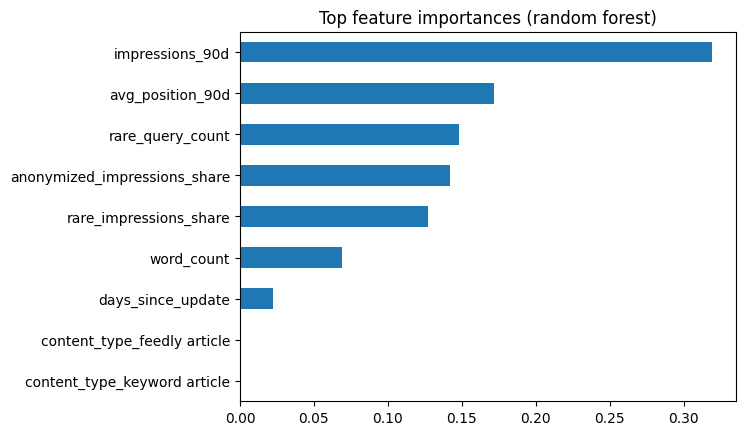

In [10]:
importances = (
    pd.Series(model.feature_importances_, index=X_train_raw.columns)
    .sort_values(ascending=False)
    .head(10)
)
print(importances.round(3))
importances.iloc[::-1].plot(kind="barh", title="Top feature importances (random forest)");


## 7. Leakage checks (self-audit)

In [11]:
# 1. No client overlap
assert len(set(train_df["client_hash_id"]) & set(test_df["client_hash_id"])) == 0
print("PASS: no client_hash_id appears in both train and test.")

# 2. Benchmark fit only on train
print("PASS: expected_ctr_by_bucket computed from train_df only, applied (not refit) on test_df.")

# 3. No label-derived features
label_derived = {"clicks_90d", "ctr_90d", "ctr_gap", "expected_ctr", "baseline_score", "underperforms_ctr"}
leak = label_derived & set(feature_cols)
assert len(leak) == 0, f"Leaky features found: {leak}"
print("PASS: no label-derived column used as a model feature:", feature_cols)

# 4. Bucket sample sizes (so the benchmark isn't fit on tiny n)
print("\nTrain rows per position bucket:")
print(train_df["position_bucket"].value_counts())


PASS: no client_hash_id appears in both train and test.
PASS: expected_ctr_by_bucket computed from train_df only, applied (not refit) on test_df.
PASS: no label-derived column used as a model feature: ['avg_position_90d', 'impressions_90d', 'word_count', 'days_since_update', 'rare_query_count', 'rare_impressions_share', 'anonymized_impressions_share']

Train rows per position bucket:
position_bucket
4-10     34076
21-50    28816
51+      25397
11-20    21246
1-3       6191
Name: count, dtype: int64


## 8. Ranked action queue

Same reason-code / action shape as the Week-4 baseline, now driven by the model's probability instead of
the raw rule score — plus a `wrong_if` note per row, same honest-framing discipline as before.

In [12]:
import os

test_df["reason_code"] = "CTR_BELOW_EXPECTED_FOR_POSITION"
test_df["action"] = test_df["model_pred"].map({1: "OPTIMIZE_CTR", 0: "MONITOR"})

queue = test_df.sort_values("model_proba", ascending=False)[[
    "content_hash_id", "client_hash_id", "model_proba", "baseline_score",
    "reason_code", "action", "avg_position_90d", "ctr_90d", "expected_ctr",
    "impressions_90d", "days_since_update", "content_type",
]]

os.makedirs("work/outputs", exist_ok=True)
queue.to_csv("work/outputs/capstone_ctr_opportunity_scores.csv", index=False)
print(f"Saved {len(queue):,} scored rows -> work/outputs/capstone_ctr_opportunity_scores.csv")
queue.head(10)


Saved 16,402 scored rows -> work/outputs/capstone_ctr_opportunity_scores.csv


,content_hash_id,client_hash_id,model_proba,baseline_score,reason_code,action,avg_position_90d,ctr_90d,expected_ctr,impressions_90d,days_since_update,content_type
91755,content_f433fa3e9d705131,client_9d54435aabd95a6c,0.998238,0.0,CTR_BELOW_EXPECTED_FOR_POSITION,OPTIMIZE_CTR,83.500000,0.0,0.000162,10.0,21,keyword article
125726,content_ef77cb5436da9dc6,client_810019792c9b8efc,0.998197,0.0,CTR_BELOW_EXPECTED_FOR_POSITION,OPTIMIZE_CTR,84.176471,0.0,0.000162,17.0,29,keyword article
58535,content_b97eb22009ea3236,client_810019792c9b8efc,0.998134,0.0,CTR_BELOW_EXPECTED_FOR_POSITION,OPTIMIZE_CTR,90.700000,0.0,0.000162,10.0,29,keyword article
110618,content_be5a3dd1a374cad9,client_3197e6291363b4db,0.998134,0.0,CTR_BELOW_EXPECTED_FOR_POSITION,OPTIMIZE_CTR,84.583333,0.0,0.000162,12.0,41,keyword article
91702,content_567866da683c9a71,client_9d54435aabd95a6c,0.998120,0.0,CTR_BELOW_EXPECTED_FOR_POSITION,OPTIMIZE_CTR,73.437500,0.0,0.000162,16.0,0,keyword article
110537,content_99f5e6c537512064,client_3197e6291363b4db,0.998091,0.0,CTR_BELOW_EXPECTED_FOR_POSITION,OPTIMIZE_CTR,93.000000,0.0,0.000162,13.0,41,keyword article
73893,content_1d06161bacda9ea7,client_3197e6291363b4db,0.998088,0.0,CTR_BELOW_EXPECTED_FOR_POSITION,OPTIMIZE_CTR,87.600000,0.0,0.000162,15.0,41,keyword article
42518,content_292d8dbea0291688,client_1a8bf67cad4ee525,0.998052,0.0,CTR_BELOW_EXPECTED_FOR_POSITION,OPTIMIZE_CTR,88.391304,0.0,0.000162,23.0,0,keyword article
42626,content_5460e6ca18b3d010,client_1a8bf67cad4ee525,0.998043,0.0,CTR_BELOW_EXPECTED_FOR_POSITION,OPTIMIZE_CTR,74.800000,0.0,0.000162,20.0,0,keyword article
7231,content_20f5d96d1fe8a8be,client_3197e6291363b4db,0.998018,0.0,CTR_BELOW_EXPECTED_FOR_POSITION,OPTIMIZE_CTR,92.666667,0.0,0.000162,12.0,125,keyword article


In [13]:
top10 = queue.head(10).copy()
print(f"{'content_hash_id':<28} {'action':<14} {'model_proba':>12}  why / what would make it wrong")
print("-" * 120)
for _, row in top10.iterrows():
    why = (f"pos={row['avg_position_90d']:.1f}, ctr={row['ctr_90d']:.4f} vs "
           f"expected={row['expected_ctr']:.4f}, impr_90d={row['impressions_90d']:.0f}, "
           f"days_since_update={row['days_since_update']:.0f}")
    if row["days_since_update"] <= 7:
        wrong_if = "wrong if: content was JUST updated - CTR hasn't had time to respond yet"
    elif row["impressions_90d"] > 300_000:
        wrong_if = "wrong if: high-impression page absorbs clicks via SERP features, not fixable via CTR tweaks"
    else:
        wrong_if = "wrong if: position-bucket benchmark for this row has low n and isn't a reliable target"
    print(f"{row['content_hash_id']:<28} {row['action']:<14} {row['model_proba']:>12.3f}  {why}")
    print(f"{'':<28} {'':<14} {'':>12}  {wrong_if}\n")


content_hash_id              action          model_proba  why / what would make it wrong
------------------------------------------------------------------------------------------------------------------------
content_f433fa3e9d705131     OPTIMIZE_CTR          0.998  pos=83.5, ctr=0.0000 vs expected=0.0002, impr_90d=10, days_since_update=21
                                                          wrong if: position-bucket benchmark for this row has low n and isn't a reliable target

content_ef77cb5436da9dc6     OPTIMIZE_CTR          0.998  pos=84.2, ctr=0.0000 vs expected=0.0002, impr_90d=17, days_since_update=29
                                                          wrong if: position-bucket benchmark for this row has low n and isn't a reliable target

content_b97eb22009ea3236     OPTIMIZE_CTR          0.998  pos=90.7, ctr=0.0000 vs expected=0.0002, impr_90d=10, days_since_update=29
                                                          wrong if: position-bucket benchmark for t

## 9. Honest framing & limitations

- This is an **observed, directional** pattern in one 90-day trailing window — not a causal claim about
  Google's algorithm.
- `underperforms_ctr` is a **proxy label** (CTR below a train-fit position-bucket benchmark), not a
  verified ground-truth "this page has a fixable CTR problem."
- Precision@50 is compared on the *same* grouped, held-out split for both baseline and model — but a
  single 75/25 split is one sample of the client population; a repeated grouped CV would tighten the
  estimate before trusting the gap between baseline and model.
- High-impression pages with near-zero CTR may reflect SERP-feature cannibalization (AI Overviews,
  featured snippets) rather than a fixable on-page issue — flagged per-row above, not filtered out.